In [130]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/murtazaabdullah2010/smartcargo-ojia-11-12-2025/test_data .csv
/kaggle/input/datasets/murtazaabdullah2010/smartcargo-ojia-11-12-2025/train_data.csv
/kaggle/input/datasets/murtazaabdullah2010/smartcargo-ojia-11-12-2025/sample_output.csv


In [162]:
train_ds = pd.read_csv("/kaggle/input/datasets/murtazaabdullah2010/smartcargo-ojia-11-12-2025/train_data.csv")
test_ds = pd.read_csv("/kaggle/input/datasets/murtazaabdullah2010/smartcargo-ojia-11-12-2025/test_data .csv")
sample_sub = pd.read_csv("/kaggle/input/datasets/murtazaabdullah2010/smartcargo-ojia-11-12-2025/sample_output.csv")

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

In [164]:
train_ds

,ID,City A,City B,Distance,Time of Day,Weather,Traffic,Road Quality,Driver Experience,deliver_time
0,1,Satu Mare,Suceava,352,452,Fog,154.014691,370,30,355
1,2,Ploiesti,Timisoara,519,1386,Clear,949.697532,701,2,529
2,3,Deva,Bacau,457,91,Fog,387.019309,45,26,465
3,4,Hunedoara,Focsani,447,1120,Clear,130.544017,643,6,441
4,5,Hunedoara,Arad,201,1096,Clear,619.557737,375,20,230
...,...,...,...,...,...,...,...,...,...,...
9995,9996,Targoviste,Targu Mures,280,907,Rain,563.783292,283,39,296
9996,9997,Brasov,Iasi,320,1409,Fog,189.985776,646,23,336
9997,9998,Botosani,Deva,506,890,Clear,337.350595,476,40,479
9998,9999,Iasi,Suceava,145,1086,Clear,454.312259,726,31,161


In [165]:
test_ds

,ID,City A,City B,Distance,Time of Day,Weather,Traffic,Road Quality,Driver Experience
0,10001,Hunedoara,Bucuresti,396,720,Snow,167.188657,683,31
1,10002,Hunedoara,Targu Mures,206,566,Snow,831.035451,395,26
2,10003,Iasi,Satu Mare,470,97,Clear,924.069181,220,12
3,10004,Roman,Galati,213,1170,Clear,885.273446,614,11
4,10005,Resita,Cluj-Napoca,324,192,Clear,851.316241,494,23
...,...,...,...,...,...,...,...,...,...
1995,11996,Barlad,Craiova,522,73,Snow,322.377659,317,2
1996,11997,Focsani,Cluj-Napoca,420,536,Clear,468.861436,55,9
1997,11998,Craiova,Drobeta-Turnu Severin,110,388,Rain,493.491538,390,36
1998,11999,Iasi,Ploiesti,376,1002,Rain,68.909446,826,5


In [166]:
sample_sub.loc[sample_sub["subtaskID"] == 1, "answer"] = len(
    test_ds[(test_ds["City A"] == "Barlad") & (test_ds["Weather"] == "Fog")]
)
sample_sub

,Unnamed: 0,subtaskID,datapointID,answer
0,0,1,1,15.0
1,1,2,10001,464.3
2,2,2,10002,245.5
3,3,2,10003,492.0
4,4,2,10004,274.4
...,...,...,...,...
1996,1996,2,11996,553.7
1997,1997,2,11997,425.5
1998,1998,2,11998,149.0
1999,1999,2,11999,458.6


In [167]:
y_col = "deliver_time"

In [168]:
train_ds

,ID,City A,City B,Distance,Time of Day,Weather,Traffic,Road Quality,Driver Experience,deliver_time
0,1,Satu Mare,Suceava,352,452,Fog,154.014691,370,30,355
1,2,Ploiesti,Timisoara,519,1386,Clear,949.697532,701,2,529
2,3,Deva,Bacau,457,91,Fog,387.019309,45,26,465
3,4,Hunedoara,Focsani,447,1120,Clear,130.544017,643,6,441
4,5,Hunedoara,Arad,201,1096,Clear,619.557737,375,20,230
...,...,...,...,...,...,...,...,...,...,...
9995,9996,Targoviste,Targu Mures,280,907,Rain,563.783292,283,39,296
9996,9997,Brasov,Iasi,320,1409,Fog,189.985776,646,23,336
9997,9998,Botosani,Deva,506,890,Clear,337.350595,476,40,479
9998,9999,Iasi,Suceava,145,1086,Clear,454.312259,726,31,161


In [169]:
cat_cols = ["City A", "City B", "Weather"]
for col in cat_cols:
    print(train_ds[col].nunique())

34
34
4


In [170]:
for col in cat_cols:
    print(test_ds[col].nunique())

34
34
4


In [171]:
num_cols = [col for col in test_ds.columns if col not in cat_cols]
num_cols.remove("ID")

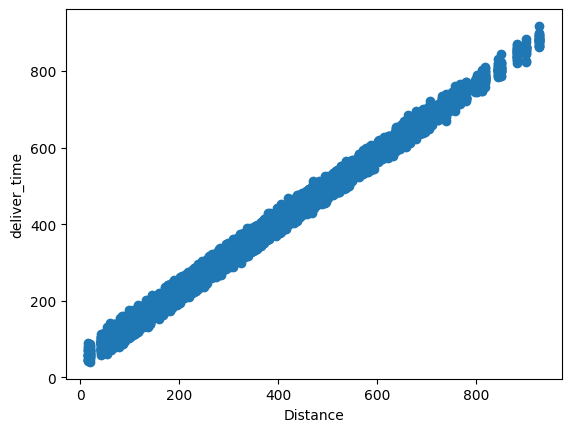

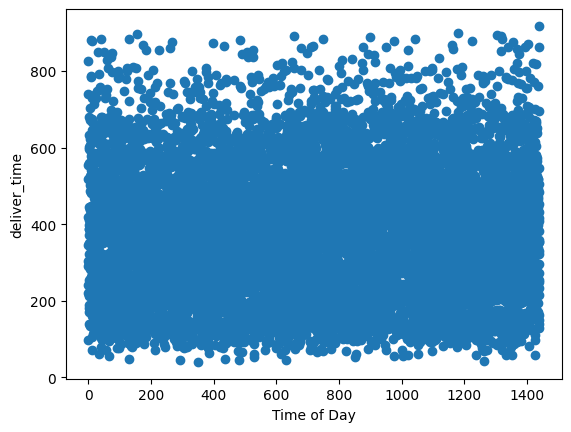

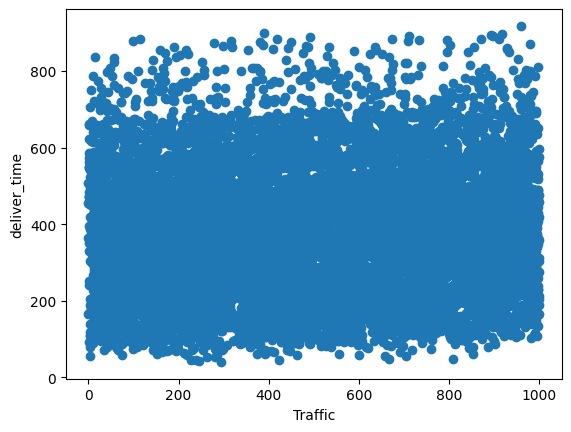

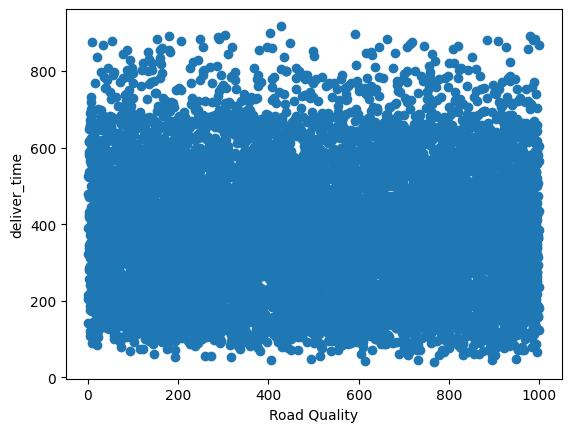

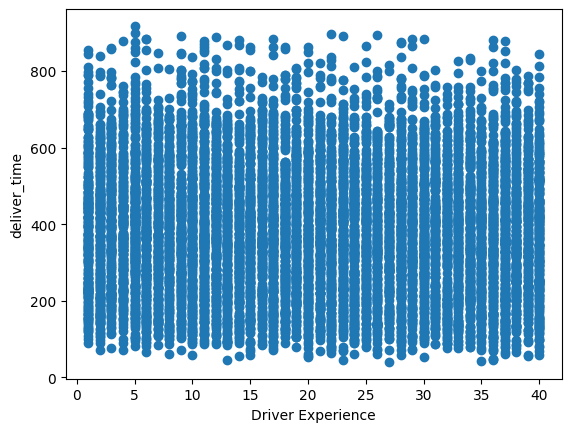

In [172]:
for col in num_cols:
    plt.scatter(train_ds[col], train_ds[y_col])
    plt.xlabel(col)
    plt.ylabel(y_col)
    plt.show()

In [173]:
y_col

'deliver_time'

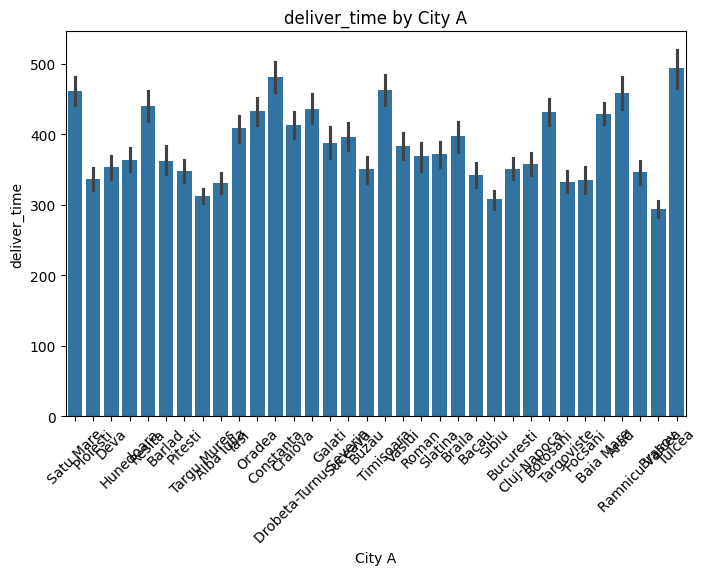

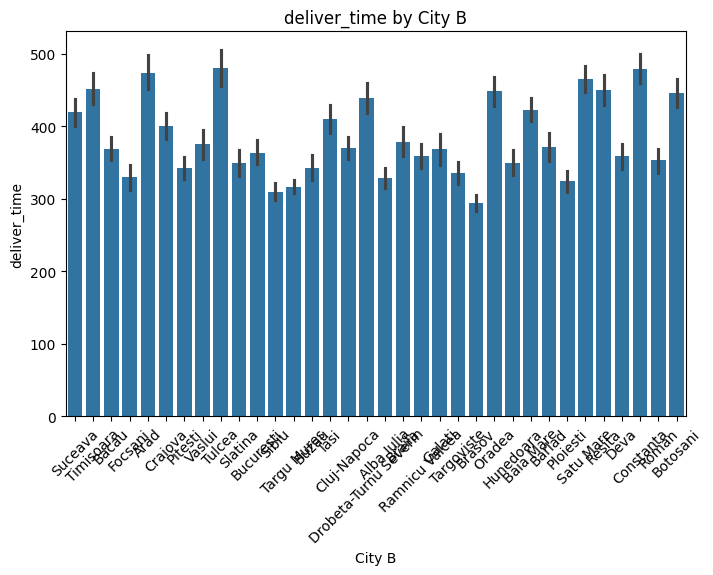

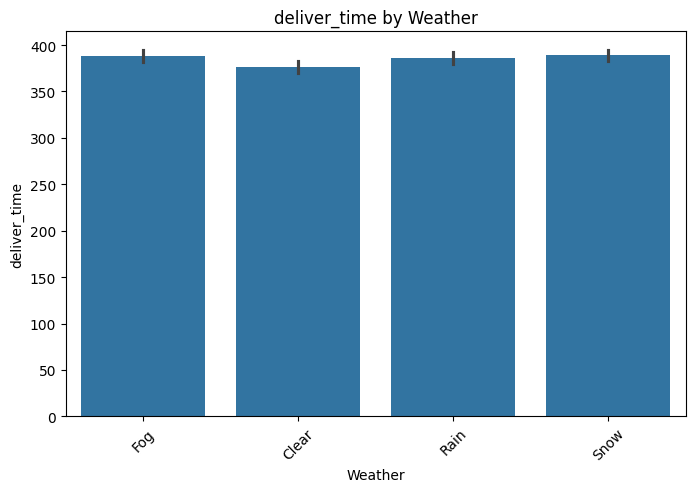

In [174]:
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=train_ds, x=col, y=y_col)
    plt.title(f"{y_col} by {col}")
    plt.xticks(rotation=45)
    plt.show()

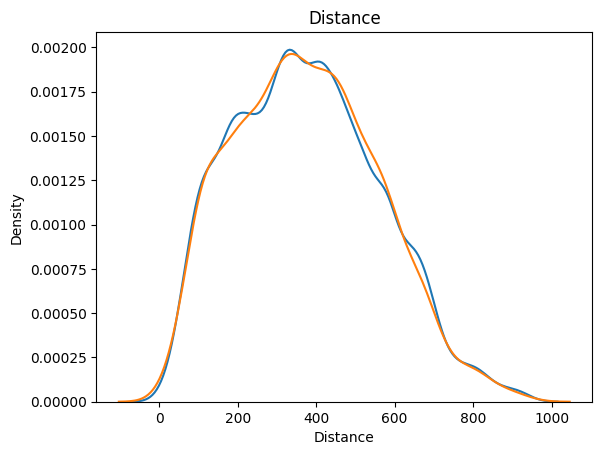

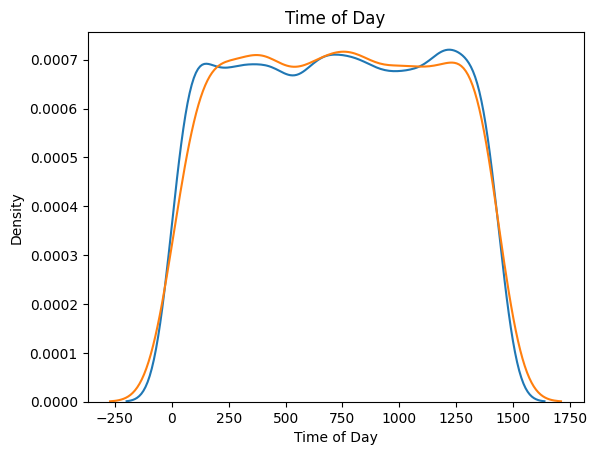

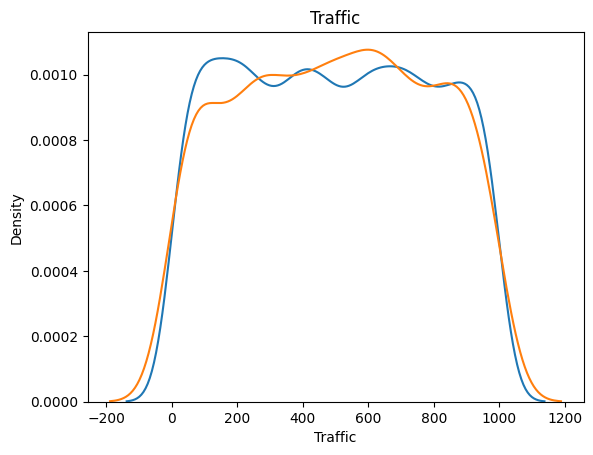

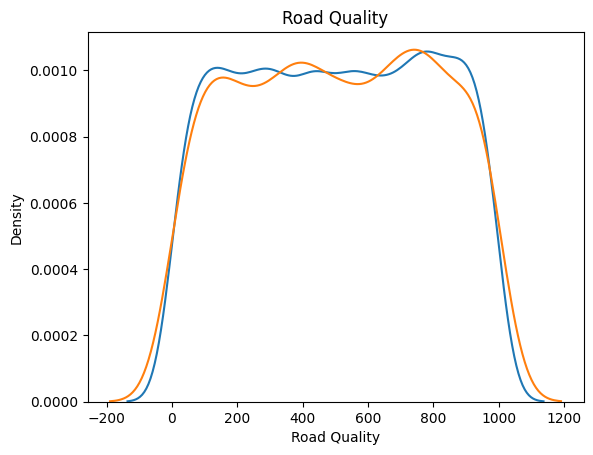

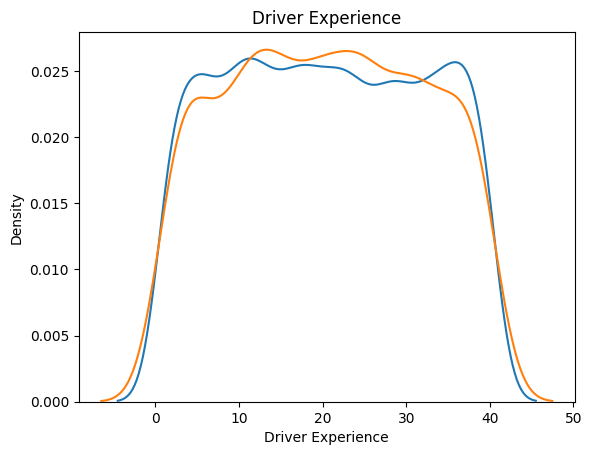

In [175]:
for col in num_cols:
    sns.kdeplot(train_ds[col])
    sns.kdeplot(test_ds[col])
    plt.title(col)
    plt.show()

In [176]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

scaler= StandardScaler()
train_ds[num_cols] = scaler.fit_transform(train_ds[num_cols])
test_ds[num_cols] = scaler.transform(test_ds[num_cols])

encoder= OrdinalEncoder()
train_ds[cat_cols] = encoder.fit_transform(train_ds[cat_cols])
test_ds[cat_cols] = encoder.transform(test_ds[cat_cols])


In [177]:
from xgboost import XGBRegressor
print(len(train_ds))
X_cols = list(cat_cols) + list(num_cols)
xgb = XGBRegressor(n_estimators = 1000).fit(train_ds[X_cols], train_ds[y_col])

10000


In [178]:
len(test_ds), len(sample_sub)

(2000, 2001)

In [179]:
sample_sub

,Unnamed: 0,subtaskID,datapointID,answer
0,0,1,1,15.0
1,1,2,10001,464.3
2,2,2,10002,245.5
3,3,2,10003,492.0
4,4,2,10004,274.4
...,...,...,...,...
1996,1996,2,11996,553.7
1997,1997,2,11997,425.5
1998,1998,2,11998,149.0
1999,1999,2,11999,458.6


In [180]:
sample_sub.loc[sample_sub["subtaskID"] == 2, "answer"] = xgb.predict(test_ds[X_cols])
sample_sub

,Unnamed: 0,subtaskID,datapointID,answer
0,0,1,1,15.000000
1,1,2,10001,384.837616
2,2,2,10002,241.981979
3,3,2,10003,480.378815
4,4,2,10004,245.151138
...,...,...,...,...
1996,1996,2,11996,516.869873
1997,1997,2,11997,428.095795
1998,1998,2,11998,135.379395
1999,1999,2,11999,370.533203


In [181]:
sample_sub.to_csv("oniasub2.csv", index = False)